In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

1 - Packages
First, let's run the cell below to import all the packages that you will need during this assignment.

numpy is the fundamental package for working with matrices in Python.
matplotlib is a famous library to plot graphs in Python.
utils.py contains helper functions for this assignment. You do not need to modify code in this file.


2 - Problem Statement
Suppose you are the CEO of a restaurant franchise and are considering different cities for opening a new outlet.

You would like to expand your business to cities that may give your restaurant higher profits.
The chain already has restaurants in various cities and you have data for profits and populations from the cities.
You also have data on cities that are candidates for a new restaurant.
For these cities, you have the city population.
Can you use the data to help you identify which cities may potentially give your business higher profits?

3 - Dataset
You will start by loading the dataset for this task.

The load_data() function shown below loads the data into variables x_train and y_train
x_train is the population of a city
y_train is the profit of a restaurant in that city. A negative value for profit indicates a loss.
Both X_train and y_train are numpy arrays.

In [4]:
# load the dataset
x_train, y_train = load_data()

View the variables
Before starting on any task, it is useful to get more familiar with your dataset.

A good place to start is to just print out each variable and see what it contains.
The code below prints the variable x_train and the type of the variable.

In [5]:
# print x_train
print("Type of x_train:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5]) 

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]


x_train is a numpy array that contains decimal values that are all greater than zero.

These values represent the city population times 10,000
For example, 6.1101 means that the population for that city is 61,101
Now, let's print y_train

In [6]:
# print y_train
print("Type of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5])  

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


Similarly, y_train is a numpy array that has decimal values, some negative, some positive.

These represent your restaurant's average monthly profits in each city, in units of $10,000.
For example, 17.592 represents $175,920 in average monthly profits for that city.
-2.6807 represents -$26,807 in average monthly loss for that city.
Check the dimensions of your variables
Another useful way to get familiar with your data is to view its dimensions.

Please print the shape of x_train and y_train and see how many training examples you have in your dataset.

In [7]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


The city population array has 97 data points, and the monthly average profits also has 97 data points. These are NumPy 1D arrays.

Visualize your data
It is often useful to understand the data by visualizing it.

For this dataset, you can use a scatter plot to visualize the data, since it has only two properties to plot (profit and population).
Many other problems that you will encounter in real life have more than two properties (for example, population, average household income, monthly profits, monthly sales).When you have more than two properties, you can still use a scatter plot to see the relationship between each pair of properties.

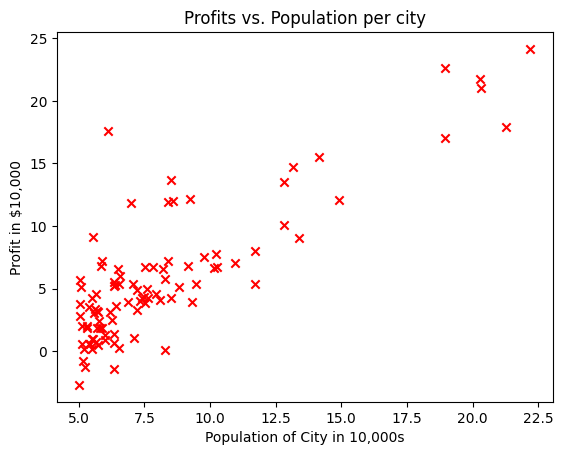

In [8]:
# Create a scatter plot of the data. To change the markers to red "x",
# we used the 'marker' and 'c' parameters
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

In [35]:
# UNQ_C1
# GRADED FUNCTION: compute_cost

def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
        x (ndarray): Shape (m,) Input to the model (Population of cities) 
        y (ndarray): Shape (m,) Label (Actual profits for the cities)
        w, b (scalar): Parameters of the model
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    # You need to return this variable correctly
    total_cost = 0
    
    ### START CODE HERE ###
    cost = 0
    
    for i in range(m):
        f_wb=w*x[i]+b;
        cost = cost + (f_wb-y[i])**2
        
    total_cost = cost/(2*m)
    print("totalcost",total_cost)
    ### END CODE HERE ### 

    return total_cost

In [36]:
# Compute cost with some initial values for paramaters w, b
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}')

# Public tests
from public_tests import *
compute_cost_test(compute_cost)

totalcost 75.20338497891959
<class 'numpy.float64'>
Cost at initial w: 75.203
totalcost 0.0
totalcost 2.0
totalcost 15.325
totalcost 10.725
totalcost 4.525
All tests passed!


Expected Output:

Cost at initial w: 75.203


Exercise 2
Please complete the compute_gradient function to:

Iterate over the training examples, and for each example, compute:

The prediction of the model for that example
𝑓𝑤𝑏(𝑥(𝑖))=𝑤𝑥(𝑖)+𝑏
 

The gradient for the parameters  𝑤,𝑏
  from that example
∂𝐽(𝑤,𝑏)∂𝑏(𝑖)=(𝑓𝑤,𝑏(𝑥(𝑖))−𝑦(𝑖))
 
∂𝐽(𝑤,𝑏)∂𝑤(𝑖)=(𝑓𝑤,𝑏(𝑥(𝑖))−𝑦(𝑖))𝑥(𝑖)
 

Return the total gradient update from all the examples
∂𝐽(𝑤,𝑏)∂𝑏=1𝑚∑𝑖=0𝑚−1∂𝐽(𝑤,𝑏)∂𝑏(𝑖)
 

∂𝐽(𝑤,𝑏)∂𝑤=1𝑚∑𝑖=0𝑚−1∂𝐽(𝑤,𝑏)∂𝑤(𝑖)
 

Here,  𝑚
  is the number of training examples and  ∑
  is the summation operator
If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [37]:
# UNQ_C2
# GRADED FUNCTION: compute_gradient
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]
    
    # You need to return the following variables correctly
    dj_dw = 0
    dj_db = 0
    
    ### START CODE HERE ###

    for i in range(m):
        f_wb=w*x[i]+b;
        tmp_w = (f_wb - y[i])*x[i]
        tmp_d = f_wb - y[i]
        dj_dw = dj_dw+tmp_w
        dj_db = dj_db+tmp_d

    dj_dw = (dj_dw)/m
    dj_db = (dj_db)/m
    
    ### END CODE HERE ### 
        
    return dj_dw, dj_db

In [38]:
# Compute and display gradient with w initialized to zeroes
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

compute_gradient_test(compute_gradient)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


Gradient at initial , b (zeros)	-65.32884975 -5.83913505154639

In [39]:
# Compute and display cost and gradient with non-zero w -47.41610118114435 -4.007175051546391
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: -47.41610118114435 -4.007175051546391


In [40]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      w_in, b_in : (scalar) Initial values of parameters of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(x)
    
    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b )  

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history #return w and J,w history for graphing

In [41]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

totalcost 6.737190464870008
Iteration    0: Cost     6.74   
totalcost 5.931593568604957
totalcost 5.901154707081387
totalcost 5.89522858644422
totalcost 5.890094943117333
totalcost 5.885004158443646
totalcost 5.879932480491416
totalcost 5.874879094762575
totalcost 5.8698439118063845
totalcost 5.8648268653129305
totalcost 5.8598278899321805
totalcost 5.85484692057229
totalcost 5.849883892376585
totalcost 5.844938740722036
totalcost 5.840011401218365
totalcost 5.835101809707228
totalcost 5.830209902261389
totalcost 5.825335615183866
totalcost 5.820478885007098
totalcost 5.8156396484921515
totalcost 5.81081784262787
totalcost 5.806013404630042
totalcost 5.801226271940627
totalcost 5.796456382226899
totalcost 5.791703673380652
totalcost 5.786968083517397
totalcost 5.782249550975539
totalcost 5.777548014315598
totalcost 5.772863412319381
totalcost 5.768195683989212
totalcost 5.76354476854712
totalcost 5.758910605434049
totalcost 5.754293134309077
totalcost 5.7496922950486296
totalcost 5.74

Expected Output:

w, b found by gradient descent	1.16636235 -3.63029143940436
We will now use the final parameters from gradient descent to plot the linear fit.

Recall that we can get the prediction for a single example 𝑓(𝑥(𝑖))=𝑤𝑥(𝑖)+𝑏
.

To calculate the predictions on the entire dataset, we can loop through all the training examples and calculate the prediction for each example. This is shown in the code block below.



In [42]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

Text(0.5, 0, 'Population of City in 10,000s')

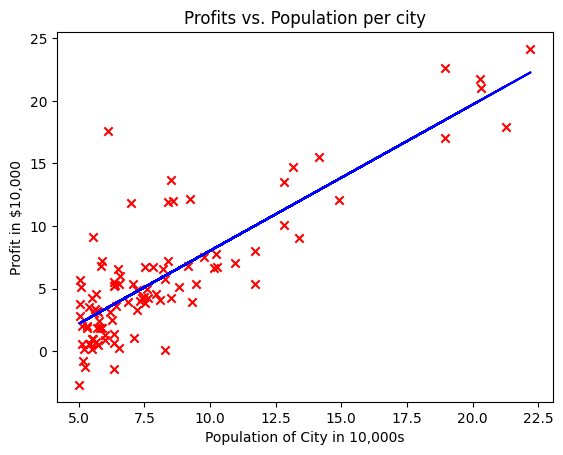

In [43]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')

Your final values of  𝑤,𝑏
  can also be used to make predictions on profits. Let's predict what the profit would be in areas of 35,000 and 70,000 people.

The model takes in population of a city in 10,000s as input.

Therefore, 35,000 people can be translated into an input to the model as np.array([3.5])

Similarly, 70,000 people can be translated into an input to the model as np.array([7.])

In [44]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


Expected Output:

For population = 35,000, we predict a profit of	$4519.77
For population = 70,000, we predict a profit of	$45342.45
Congratulations on completing this practice lab on linear regression! Next week, you will create models to solve a different type of problem: classification. See you there!